In [1]:
# rsync -avz cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/perf_dal_new.db /home/phahn/repositories/dal-toolbox/publications/perf_dal/notebooks/perf_dal_new.db

In [2]:
import mlflow
import numpy as np
import pylab as plt
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib as mpl
from cycler import cycler

# Define a custom style dictionary
custom_style = {
    # Figure and axes
    "figure.figsize": (10, 6),
    "figure.dpi": 100,
    "axes.facecolor": "white",
    "axes.edgecolor": "lightgray",
    
    # Lines and markers
    "lines.linewidth": 1.5,
    "lines.markersize": 6,

    # Font settings
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],

    # Save figure settings
    "savefig.dpi": 300,
}

# Update matplotlib's global rcParams with your custom style
mpl.rcParams.update(custom_style)
mpl.rcParams['axes.grid'] = True
mpl.rcParams["grid.linestyle"] = '--'
mpl.rcParams["grid.linewidth"] = .5
mpl.rcParams["grid.alpha"] = 0.7
# mpl.rcParams['axes.prop_cycle'] = cycler("color", plt.get_cmap("Set2").colors)
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["#6C8EBF", "#D45D5D", "#5C985C", "#D9822B", "#9C7AA1", "#DAB66C", "#A2D5C6", "#E699B3"])
    # "grid.color": "gray",

import os
from pathlib import Path

plot_dir = Path('/home/dhuseljic/paper_plots/perf_dal/')
os.makedirs(plot_dir, exist_ok=True)

# uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/perf_dal_2.db'
uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/perfdal.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)

# uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/perf_dal_2.db'
for exp in client.search_experiments():
    print(exp.name)

abl_tiny_new_1
abl_tiny_new_2
abl_tiny_new_3
abl_tiny_3
abl_tiny_2
abl_tiny_1
abl_weak_oracle_investigation
abl_example
abl_extreme_reduction
abl_robustness
abl_vary_sss_3
abl_repr_vs_unc_3_4
abl_repr_vs_unc_3_3
abl_repr_vs_unc_3_2
abl_repr_vs_unc_3_1
abl_vary_sss_2_new
abl_vary_sss_2
abl_repr_vs_unc_2_4
abl_repr_vs_unc_2_3
abl_repr_vs_unc_2_2
abl_repr_vs_unc_2_1
abl_one_batch_per_strat_2
abl_repr_vs_unc
abl_one_batch_per_strat
abl_retraining_epochs
abl_perf_est
abl_num_batches
abl_acq_size_new
abl_vary_sss
swinv2_oracle
dinov2_oracle
swinv2_baselines
dinov2_baselines
Default


In [3]:

exps = [
    'dinov2_baselines', # Baselines on DinoV2
]

datasets = {'cifar10': 10, 'stl10':10, 'snacks':20, 'flowers102':25, 'dopanim': 15,  'dtd':50, 'food101':100, 'cifar100':100, 'tiny_imagenet': 200, 'imagenet':1000}

## State-of-the-Art Results

In [19]:
# Dataset information

# Load in all results
all_acc_curves_strategies = {}
all_pick_choices = {}

backbone = 'dinov2'
experiment_name = f"{backbone}_baselines"
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)

for run in runs_strategies:
    if len(run.data.params) == 0: continue
    key = run.data.params['al.strategy']
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])


experiment_name = f"{backbone}_oracle"
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)

for ds_name in all_acc_curves_strategies:
    ds_results = all_acc_curves_strategies[ds_name]
    print(ds_name)
    for strat_name in ds_results:
        print("> {:15} {:10}".format(strat_name, len(ds_results[strat_name])))

for run in runs_strategies:
    key = run.data.params['al.strategy']
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

for ds_name in all_acc_curves_strategies:
    ds_results = all_acc_curves_strategies[ds_name]
    print(ds_name)
    for strat_name in ds_results:
        print("> {:15} {:10}".format(strat_name, len(ds_results[strat_name])))

imagenet
> typiclust               10
> random                  10
> margin                  10
> dropquery               10
> coreset                 10
> badge                   10
> bait                    10
> alfamix                 10
tiny_imagenet
> typiclust               10
> random                  10
> margin                  10
> dropquery               10
> coreset                 10
> bait                    10
> badge                   10
> alfamix                 10
cifar100
> typiclust               10
> random                  10
> margin                  10
> dropquery               10
> coreset                 10
> bait                    10
> badge                   10
> alfamix                 10
food101
> typiclust               10
> random                  10
> margin                  10
> dropquery               10
> coreset                 10
> bait                    10
> badge                   10
> alfamix                 10
dopanim
> typiclust             

In [20]:
for dset in datasets:
    for strat in all_acc_curves_strategies[dset]:
        if len(all_acc_curves_strategies[dset][strat]) < 10:
            print('Missing runs in', dset, strat, len(all_acc_curves_strategies[dset][strat]))

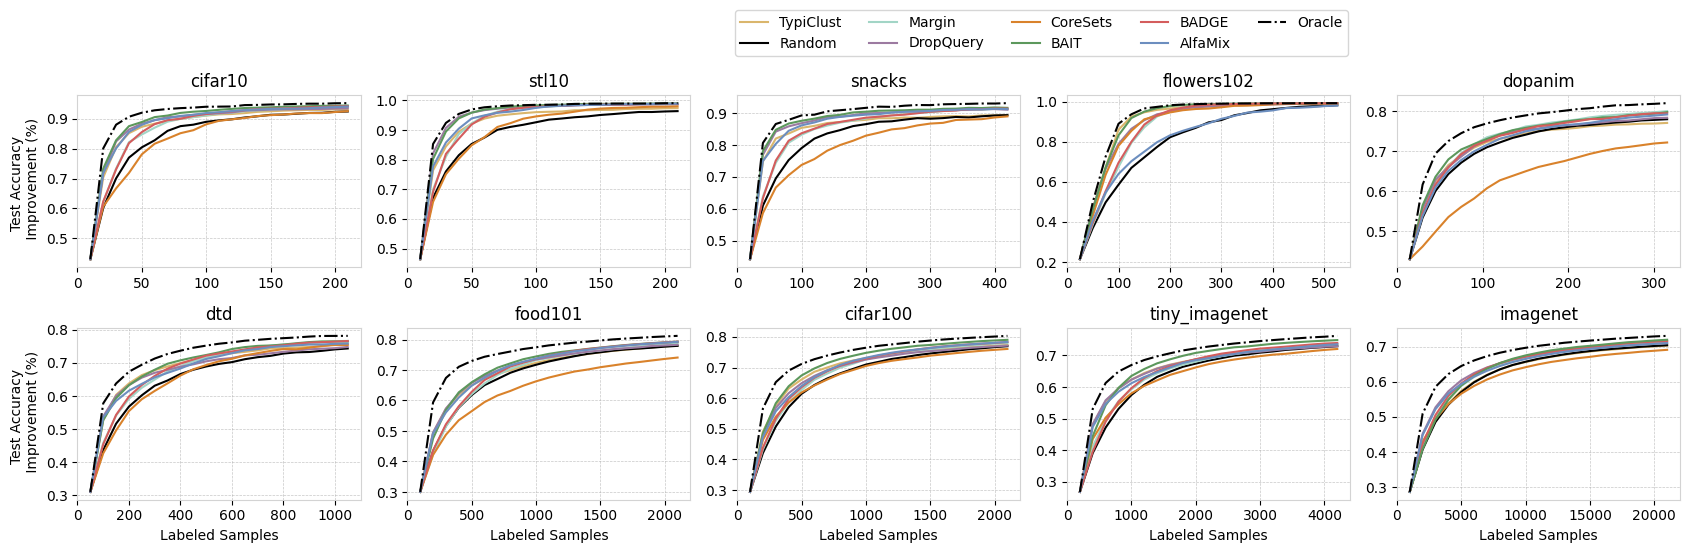

In [21]:
# To remove a query strategy from the plot, comment it out.
Q = {
    'alfamix' :         dict(c='C0', ls='-', alpha=1, label='AlfaMix'),
    'badge' :           dict(c='C1', ls='-', alpha=1, label='BADGE'),
    'bait' :            dict(c='C2', ls='-', alpha=1, label='BAIT'),
    'coreset' :         dict(c='C3', ls='-', alpha=1, label='CoreSets'),
    'dropquery' :       dict(c='C4', ls='-', alpha=1, label='DropQuery'),
    'typiclust' :       dict(c='C5', ls='-', alpha=1, label='TypiClust'),
    'margin' :          dict(c='C6', ls='-', alpha=1, label='Margin'),
    'random' :          dict(c='k' , ls='-', alpha=1, label='Random'),
    'perf_dal_oracle' : dict(c='k', ls='-.', alpha=1, label='Oracle'),
}
fig, ax = plt.subplots(nrows=2, ncols=5, tight_layout=True, figsize=(17, 5))

for i, dset in enumerate(datasets):
    plt.axes(ax[i//5, i%5])
    acqs = datasets[dset]
    x_ticks = [i*acqs for i in range(1, 22)]

    # plt.hlines(y=0, xmin=x_ticks[0], xmax=x_ticks[-1], colors='black', linestyles='-', label='Random')
    ylim = (0, 0)
    for strategy, accs in all_acc_curves_strategies[dset].items():
        if strategy in Q:
            values = np.mean(accs, axis=0) # - np.mean(all_acc_curves_strategies[dset]['random'], axis=0)
            ylim = (min(ylim[0], min(values) - 0.025), max(ylim[1], max(values) + 0.025))
            plt.plot(x_ticks, values, **Q[strategy])
    if i // 5 == 1:
        plt.xlabel('Labeled Samples')
    if i % 5 == 0:
        plt.ylabel('Test Accuracy \n Improvement (%)')
    plt.title(dset)
    plt.grid(True)
    # plt.xlim((x_ticks[0], x_ticks[-1]))
    # plt.ylim(ylim)
    # plt.ylim(bottom=-0.02)
    if dset == 'cifar10':
        handles, labels = plt.gca().get_legend_handles_labels()
        
fig.legend(loc="right", bbox_to_anchor=[.8, 1.05], handles=handles, labels=labels, ncols=5)
plt.savefig(plot_dir / f'lc_acc_sota_{backbone}.pdf', bbox_inches='tight')
plt.show()

### What was bought

In [58]:
all_pick_choices = defaultdict(list)

backbone = 'swinv2'
experiment_name = f"{backbone}_oracle"
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)

for run in runs_strategies:
    strat = run.data.params['al.strategy']
    dataset = run.data.params['dataset_name']
    if run.data.params['backbone'] != backbone:
        continue
    metric_names = [m for m in run.data.metrics if 'bought' in m]
    pick_matrix = [v.value for m in metric_names for v in client.get_metric_history(run.info.run_id, m)]
    pick_matrix = [[v.value for v in client.get_metric_history(run.info.run_id, m)] for m in metric_names ]
    pick_matrix = np.array(pick_matrix)
    pick_matrix = pick_matrix[:, 1:] - pick_matrix[:, :-1]
    if pick_matrix.shape != (10, 20):
        continue

    all_pick_choices[dataset].append(pick_matrix)

    # plt.xticks(range(0, 21))
    # plt.yticks(range(len(metric_names)), [m.removeprefix('bought_') for m in metric_names])
    # plt.imshow(pick_matrix)
for ds in all_pick_choices:
    print("{:15}: {:3}".format(ds, len(all_pick_choices[ds])))

food101        :  10
imagenet       :  10
tiny_imagenet  :  10
cifar100       :  10
dopanim        :  10
dtd            :  10
flowers102     :  10
snacks         :  10
stl10          :  10
cifar10        :  10


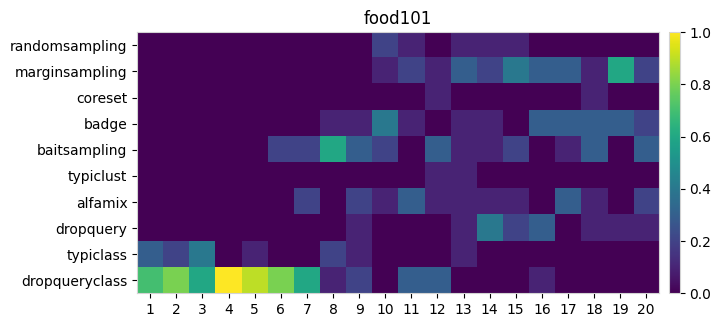

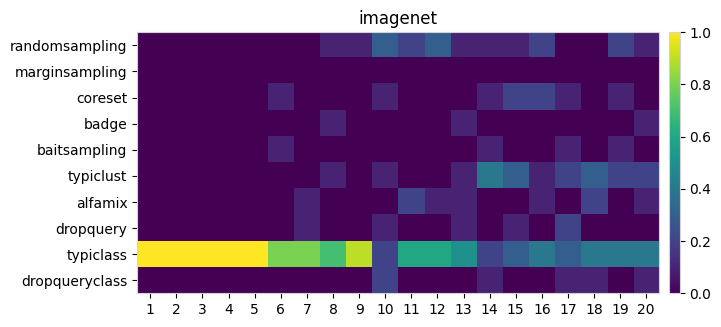

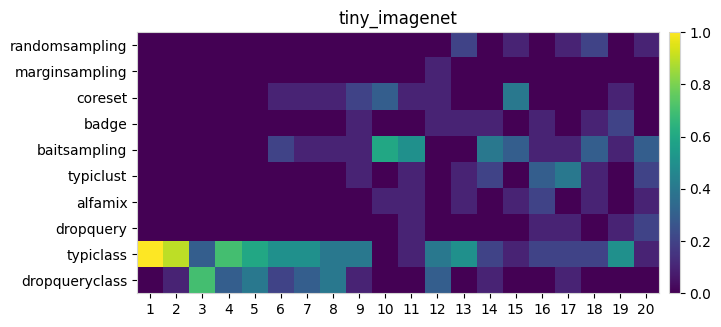

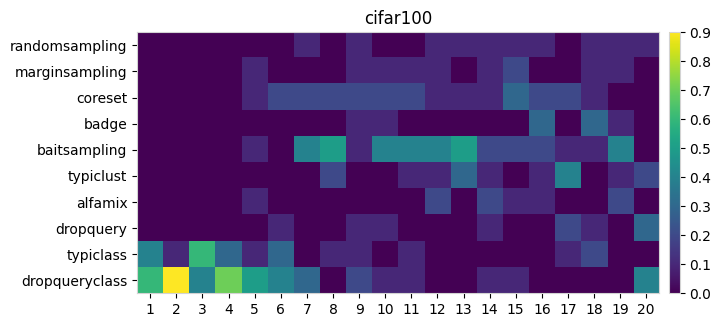

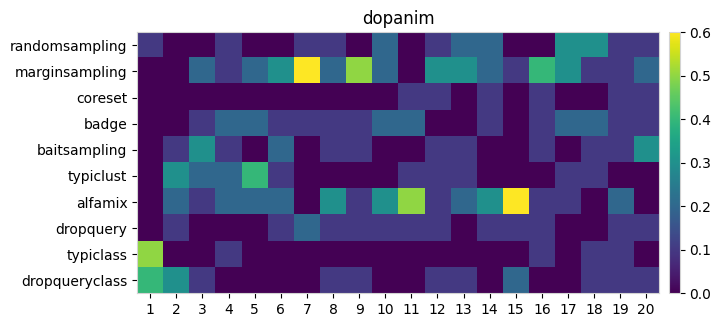

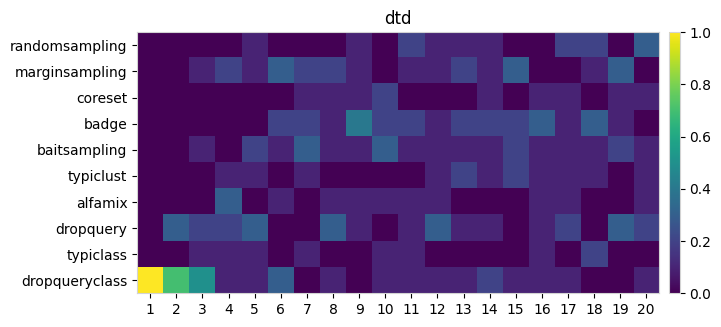

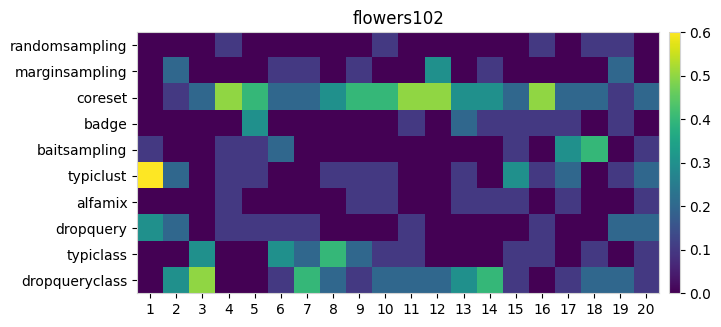

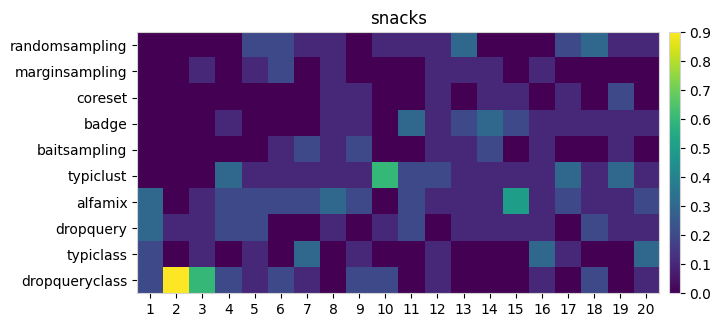

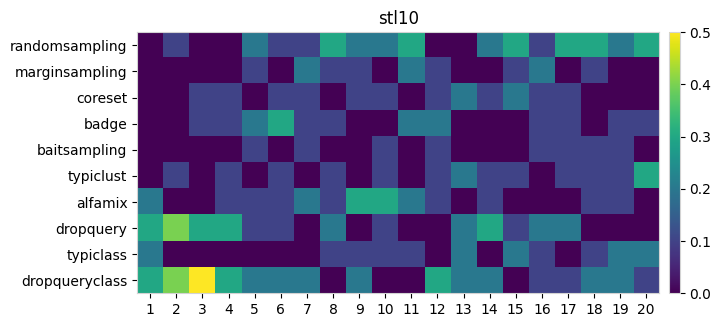

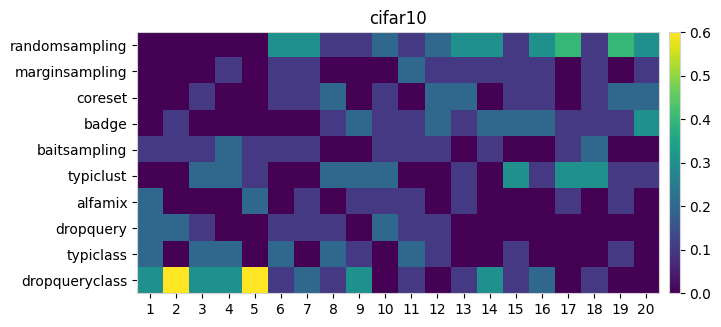

In [59]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

names = [m.removeprefix('bought_') for m in metric_names]
names_ordered = ['randomsampling', 'marginsampling', 'coreset', 'badge', 'baitsampling', 'typiclust', 'alfamix','dropquery',  
                 'typiclass', 'dropqueryclass']
order_indices = np.array([np.where(n == np.array(names))[0] for n in names_ordered]).ravel()

for ds in all_pick_choices:
    plt.figure(figsize=(7, 5))
    plt.title(ds)
    im = plt.imshow(np.mean(all_pick_choices[ds], axis=0)[order_indices])
    plt.xticks(range(0, 20), range(1, 21))
    plt.yticks(range(len(metric_names)), names_ordered)
    plt.grid()
    divider = make_axes_locatable(plt.gca())
    cax = divider.append_axes("right", size="2%", pad=0.1)
    plt.grid()
    plt.colorbar(im, cax=cax)
    plt.savefig(plot_dir / f'choices_{ds}.pdf', bbox_inches='tight')
    plt.show()

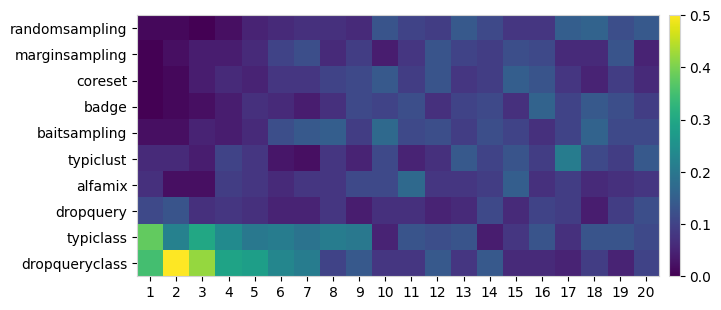

In [60]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

avg_pick_choice = np.mean([matrices for ds in all_pick_choices for matrices in all_pick_choices[ds]], axis=0)
# order = 

plt.figure(figsize=(7, 5))

im = plt.imshow(avg_pick_choice[order_indices], vmin=0, vmax=.5)
plt.xticks(range(0, 20), range(1, 21))
plt.yticks(range(len(metric_names)), names_ordered)
plt.grid()
divider = make_axes_locatable(plt.gca())
cax = divider.append_axes("right", size="2%", pad=0.1)
plt.grid()
plt.colorbar(im, cax=cax)
plt.savefig(plot_dir / f'avgchoices_{backbone}.pdf', bbox_inches='tight')
plt.show()

In [61]:
tmp = zip(names_ordered, avg_pick_choice[order_indices].mean(1).tolist())
tmp = sorted(tmp, key=lambda x: -x[1])
for name, percent in tmp:
    print("{:15} | {:.2f}".format(name, percent*100))

dropqueryclass  | 17.25
typiclass       | 16.35
baitsampling    | 9.75
typiclust       | 8.80
alfamix         | 8.30
randomsampling  | 8.25
coreset         | 8.10
badge           | 8.00
dropquery       | 7.70
marginsampling  | 7.50


## Ablations and Targeted Experiments

### Naive vs Algorithm

In [92]:
# Load in all results
all_acc_curves_strategies = {}
all_pick_choices = {}
query_times = {}

# Add Random to the list
experiment_id = client.get_experiment_by_name("abl_num_batches").experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)

for run in runs_strategies:
    key = run.data.params['al.strategy']
    dataset = run.data.params['dataset_name']

    if dataset not in ['cifar10', 'dtd']: continue
    if eval(run.data.params["al.optimal.strategies"]) == ['random']: 
        key = 'naive'
    if eval(run.data.params["al.optimal.num_batches"]) != 100:
        continue


    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    if len(accs) == 21:
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)

experiment_id = client.get_experiment_by_name("dinov2_oracle").experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)

for run in runs_strategies:
    key = run.data.params['al.strategy']
    dataset = run.data.params['dataset_name']

    if dataset not in ['cifar10', 'dtd']: continue
    if eval(run.data.params["al.optimal.strategies"]) == ['random']: 
        key = 'naive'
    if eval(run.data.params["al.optimal.num_batches"]) != 100:
        continue

    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    if len(accs) == 21:
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)

experiment_id = client.get_experiment_by_name("dinov2_baselines").experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)

for run in runs_strategies:
    key = run.data.params['al.strategy']
    dataset = run.data.params['dataset_name']

    if dataset not in ['cifar10', 'dtd']: continue
    if key != 'random': continue

    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    if len(accs) == 21:
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)

for ds_name in all_acc_curves_strategies:
    ds_results = all_acc_curves_strategies[ds_name]
    print(ds_name)
    for strat_name in ds_results:
        print("> {:15} {:10}".format(strat_name, len(ds_results[strat_name])))

dtd
> naive                   10
> perf_dal_oracle         10
> random                  10
cifar10
> naive                   10
> perf_dal_oracle         10
> random                  10


0.046953334410985294
0.06497523954936438
0.04424772078082674
0.06490628123283387


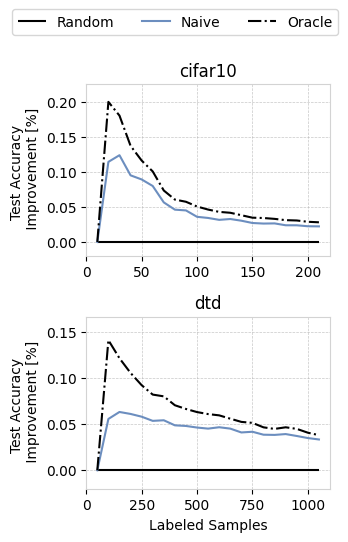

In [93]:
# To remove a query strategy from the plot, comment it out.
Q = {
    'naive' : dict(c='C0', ls='-', alpha=1, label='Naive'),
    'perf_dal_oracle' : dict(c='k', ls='-.', alpha=1, label='Oracle'),
}
fig, ax = plt.subplots(nrows=2, ncols=1, tight_layout=True, figsize=(3.5,5))

for i, dset in enumerate(['cifar10', 'dtd']):
    plt.sca(ax[i])
    acqs = datasets[dset]
    x_ticks = [i*acqs for i in range(1, 22)]

    plt.hlines(y=0, xmin=x_ticks[0], xmax=x_ticks[-1], colors='black', linestyles='-', label='Random')
    ylim = (0, 0)
    for strategy, accs in all_acc_curves_strategies[dset].items():
        if strategy in Q:
            values = np.mean(accs, axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0)
            print(np.mean(values))
            ylim = (min(ylim[0], min(values) - 0.025), max(ylim[1], max(values) + 0.025))
            plt.plot(x_ticks, values, **Q[strategy])
    if dset == 'dtd': plt.xlabel('Labeled Samples')
    plt.ylabel('Test Accuracy \n Improvement [%]')
    plt.title(dset)
    plt.grid(True)
    plt.ylim(ylim)
    plt.ylim(bottom=-0.02)
    if dset == 'cifar10':
        handles, labels = plt.gca().get_legend_handles_labels()
        
fig.legend(loc="right", bbox_to_anchor=[1, 1.05], handles=handles, labels=labels, ncols=5)
plt.savefig(plot_dir / 'lc_relacc_algo.pdf', bbox_inches='tight')
plt.show()

In [94]:
for i, dset in enumerate(['cifar10', 'dtd']):
    for strategy, accs in all_acc_curves_strategies[dset].items():
        values = np.mean(accs, axis=0)
        print(dset, strategy, np.mean(values))

cifar10 naive 0.8889680953252883
cifar10 perf_dal_oracle 0.9069900004636674
cifar10 random 0.8420147609143032
dtd naive 0.6972619051025026
dtd perf_dal_oracle 0.7179204655545098
dtd random 0.653014184321676


### Number of Batches

In [10]:
# Load in all results
all_acc_curves_strategies = {}
all_pick_choices = {}
query_times = {}

# Add Random to the list
experiment_name = exps[0]
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)

for run in runs_strategies:
    key = run.data.params['al.strategy']
    dataset = run.data.params['dataset_name']

    if key != 'random': continue
    if dataset not in ['cifar10', 'dtd']: continue

    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    if len(accs) == 21:
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)


# Add perf dal to the list
experiment_name = exps[1]
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)

for run in runs_strategies:
    key = run.data.params['al.strategy']
    if eval(run.data.params['al.optimal.strategies']) == ['random']:
        continue
    if eval(run.data.params['al.optimal.vary_strat_subset_size']) != False:
        continue
    if key == 'perf_dal_oracle':
        key = run.data.params['al.optimal.num_batches']

    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]
    if len(accs) == 21:
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)

for ds_name in all_acc_curves_strategies:
    ds_results = all_acc_curves_strategies[ds_name]
    print(ds_name)
    for strat_name in ds_results:
        print("> {:15} {:10}".format(strat_name, len(ds_results[strat_name])))

KeyError: 'al.strategy'

In [181]:
import pandas as pd

results = []
results_stderr = []
index = []

for dset in ['cifar10', 'dtd']:
    index.append(dset)
    results.append({k: np.mean(v)*100 for k,v in all_acc_curves_strategies[dset].items()})
    results_stderr.append({k: np.std(v*100, ddof=1) / np.sqrt(len(v)) for k,v in all_acc_curves_strategies[dset].items()})

df_mean = pd.DataFrame(results, index=index)
df_stderr = pd.DataFrame(results_stderr, index=index)


df_combined = (df_mean.round(2).astype(str).add('\\textsubscript{$\pm$').add(df_stderr.round(2).astype(str).add('}'))
)
col_order = ['random', '11', '55', '110']
df_combined = df_combined[col_order]
# now dump to LaTeX (± is safe ASCII, so no need to escape)
print(df_combined.to_latex())

\begin{tabular}{lllll}
\toprule
 & random & 11 & 55 & 110 \\
\midrule
cifar10 & 83.29\textsubscript{$\pm$0.04} & 89.76\textsubscript{$\pm$0.04} & 90.23\textsubscript{$\pm$0.04} & 90.45\textsubscript{$\pm$0.04} \\
dtd & 65.79\textsubscript{$\pm$0.03} & 70.9\textsubscript{$\pm$0.03} & 71.62\textsubscript{$\pm$0.03} & 71.8\textsubscript{$\pm$0.03} \\
\bottomrule
\end{tabular}



In [141]:
import pandas as pd
import numpy as np

results_mean = []
results_stderr = []
index = []

for dset in ['cifar10', 'dtd']:
    index.append(dset)
    mean_dict = {}
    stderr_dict = {}
    for strat, accs in all_acc_curves_strategies[dset].items():
        arr = np.array(accs) * 100
        mean_dict[strat]   = np.mean(arr)
        stderr_dict[strat] = np.std(arr, ddof=1) / np.sqrt(len(arr))
    results_mean.append(mean_dict)
    results_stderr.append(stderr_dict)

# build two DataFrames and then concatenate along columns with a MultiIndex
df_mean   = pd.DataFrame(results_mean,   index=index)
df_stderr = pd.DataFrame(results_stderr, index=index)
df = pd.concat(
    {'Mean (%)':   df_mean,
     'StdErr (%)': df_stderr},
    axis=1
)

# pretty LaTeX table
print(df.to_latex(
    float_format="{:.1f}".format,
    multicolumn=True,
    multicolumn_format='c'
))


\begin{tabular}{lrrrrrrrr}
\toprule
 & \multicolumn{4}{c}{Mean (%)} & \multicolumn{4}{c}{StdErr (%)} \\
 & random & 110 & 55 & 11 & random & 110 & 55 & 11 \\
\midrule
cifar10 & 83.3 & 90.5 & 90.2 & 89.8 & 4.3 & 3.8 & 3.8 & 3.8 \\
dtd & 65.8 & 71.8 & 71.6 & 70.9 & 3.4 & 3.2 & 3.2 & 3.2 \\
\bottomrule
\end{tabular}



110 0.9045438119343349
55 0.902343332483655
11 0.8976342865398952
110 0.7179660598436991
55 0.716228472334998
11 0.709007092600777


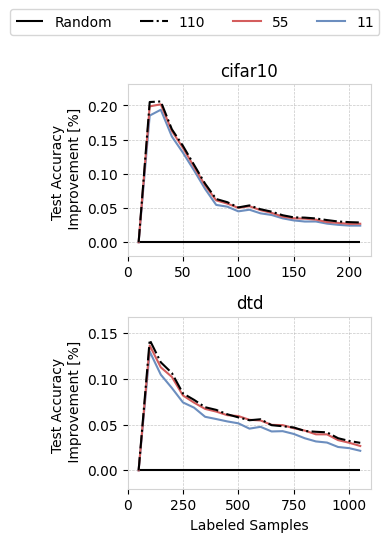

In [115]:
# To remove a query strategy from the plot, comment it out.
Q = {
    '11' : dict(c='C0', ls='-', alpha=1, label='11', zorder=3),
    '55' : dict(c='C1', ls='-', alpha=1, label='55', zorder=4),
    '110' : dict(c='k', ls='-.', alpha=1, label='110', zorder=5),
}
fig, ax = plt.subplots(nrows=2, ncols=1, tight_layout=True, figsize=(3.5,5))

for i, dset in enumerate(['cifar10', 'dtd']):
    plt.sca(ax[i])
    acqs = datasets[dset]
    x_ticks = [i*acqs for i in range(1, 22)]

    plt.hlines(y=0, xmin=x_ticks[0], xmax=x_ticks[-1], colors='black', linestyles='-', label='Random')
    ylim = (0, 0)
    for strategy, accs in all_acc_curves_strategies[dset].items():
        if strategy in Q:
            print(strategy, np.mean(accs))
            values = np.mean(accs, axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0)
            ylim = (min(ylim[0], min(values) - 0.025), max(ylim[1], max(values) + 0.025))
            plt.plot(x_ticks, values, **Q[strategy])
    if dset == 'dtd': plt.xlabel('Labeled Samples')
    plt.ylabel('Test Accuracy \n Improvement [%]')
    plt.title(dset)
    plt.grid(True)
    plt.ylim(ylim)
    plt.ylim(bottom=-0.02)
    if dset == 'cifar10':
        handles, labels = plt.gca().get_legend_handles_labels()
        
fig.legend(loc="right", bbox_to_anchor=[1, 1.05], handles=handles, labels=labels, ncols=5)
plt.savefig(plot_dir / 'lc_relacc_algo.pdf', bbox_inches='tight')
plt.show()

### Batch Size

In [16]:
all_accuracy_curves = defaultdict(lambda: defaultdict(list))

experiment_name = 'experiment_3'
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)

for run in runs_strategies:
    dataset = run.data.params['dataset_name']
    acq_size = eval(run.data.params['al.acq_size'])

    acc = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    all_accuracy_curves[dataset][acq_size].append(acc)

    # plt.xticks(range(0, 21))
    # plt.yticks(range(len(metric_names)), [m.removeprefix('bought_') for m in metric_names])
    # plt.imshow(pick_matrix)

for ds in all_accuracy_curves:
    print(ds)
    for loss in all_accuracy_curves[ds]:
        print("> {} {}".format(loss, len(all_accuracy_curves[ds][loss])))
    # print("{:15}: {:3}".format(ds, len([ds])))

cifar10
> 5 11
> 40 10
> 20 10
> 10 10
dtd
> 200 10
> 25 10
> 50 10
> 100 10
stl10
> 20 10
> 5 10
> 10 10


In [17]:
for l in all_accuracy_curves['cifar10'][5]:
    # print(len(l))
    if len(l)==39:
        all_accuracy_curves['cifar10'][5].remove(l) 

In [18]:
data = [
    (np.mean(np.mean(all_accuracy_curves['cifar10'][5 ], axis=0)[::8]), np.mean(np.mean(all_accuracy_curves['dtd'][25 ], axis=0)[::8])),
    (np.mean(np.mean(all_accuracy_curves['cifar10'][10], axis=0)[::4]), np.mean(np.mean(all_accuracy_curves['dtd'][50 ], axis=0)[::4])),
    (np.mean(np.mean(all_accuracy_curves['cifar10'][20], axis=0)[::2]), np.mean(np.mean(all_accuracy_curves['dtd'][100], axis=0)[::2])),
    (np.mean(np.mean(all_accuracy_curves['cifar10'][40], axis=0)[::1]), np.mean(np.mean(all_accuracy_curves['dtd'][200], axis=0)[::1])),
]
df = pd.DataFrame(data, index=['0.5b', '1b', '2b', '4b'], columns=['cifar10', 'dtd'])
data_std = [
    (np.mean(np.std(all_accuracy_curves['cifar10'][5 ], axis=0)[::8]), np.mean(np.std(all_accuracy_curves['dtd'][25 ], axis=0)[::8])),
    (np.mean(np.std(all_accuracy_curves['cifar10'][10], axis=0)[::4]), np.mean(np.std(all_accuracy_curves['dtd'][50 ], axis=0)[::4])),
    (np.mean(np.std(all_accuracy_curves['cifar10'][20], axis=0)[::2]), np.mean(np.std(all_accuracy_curves['dtd'][100], axis=0)[::2])),
    (np.mean(np.std(all_accuracy_curves['cifar10'][40], axis=0)[::1]), np.mean(np.std(all_accuracy_curves['dtd'][200], axis=0)[::1])),
]
df_std = pd.DataFrame(data_std, index=['0.5b', '1b', '2b', '4b'], columns=['cifar10', 'dtd'])
df_stderr = df_std / 10

df_combined = df.multiply(100).round(2).astype(str).add('\\textsubscript{$\pm$').add(df_stderr.multiply(100).round(2).astype(str).add('}'))
print(df_combined.to_latex())

\begin{tabular}{lll}
\toprule
 & cifar10 & dtd \\
\midrule
0.5b & 85.21\textsubscript{$\pm$0.19} & 64.9\textsubscript{$\pm$0.06} \\
1b & 85.1\textsubscript{$\pm$0.18} & 64.75\textsubscript{$\pm$0.06} \\
2b & 84.83\textsubscript{$\pm$0.19} & 63.85\textsubscript{$\pm$0.06} \\
4b & 84.93\textsubscript{$\pm$0.12} & 63.19\textsubscript{$\pm$0.06} \\
\bottomrule
\end{tabular}



### Performance Estimation

In [153]:
all_accuracy_curves = defaultdict(lambda: defaultdict(list))

experiment_name = "experiment_4"
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)

for run in runs_strategies:
    dataset = run.data.params['dataset_name']
    loss = run.data.params['al.optimal.loss']
    acc = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    all_accuracy_curves[dataset][loss].append(acc)


    # plt.xticks(range(0, 21))
    # plt.yticks(range(len(metric_names)), [m.removeprefix('bought_') for m in metric_names])
    # plt.imshow(pick_matrix)
for ds in all_accuracy_curves:
    print(ds)
    for loss in all_accuracy_curves[ds]:
        print("> {} {}".format(loss, len(all_accuracy_curves[ds][loss])))
    # print("{:15}: {:3}".format(ds, len([ds])))

dtd
> brier 10
> zero_one 10
> cross_entropy 10
cifar10
> brier 10
> zero_one 10
> cross_entropy 10


In [158]:
import pandas as pd

data = [
    (np.mean(all_accuracy_curves['cifar10']['zero_one']), np.mean(all_accuracy_curves['dtd']['zero_one'])),
    (np.mean(all_accuracy_curves['cifar10']['cross_entropy']), np.mean(all_accuracy_curves['dtd']['cross_entropy'])),
    (np.mean(all_accuracy_curves['cifar10']['brier']), np.mean(all_accuracy_curves['dtd']['brier'])),
]
df = pd.DataFrame(data, index=['zero_one', 'cross_entropy', 'Brier score'], columns=['cifar10', 'dtd'])

data_std = [
    (np.mean(np.std(all_accuracy_curves['cifar10']['zero_one'], 0)), np.mean(np.std(all_accuracy_curves['dtd']['zero_one'], 0))),
    (np.mean(np.std(all_accuracy_curves['cifar10']['cross_entropy'], 0)), np.mean(np.std(all_accuracy_curves['dtd']['cross_entropy'], 0))),
    (np.mean(np.std(all_accuracy_curves['cifar10']['brier'], 0)), np.mean(np.std(all_accuracy_curves['dtd']['brier'], 0))),
]
df_std = pd.DataFrame(data_std , index=['zero_one', 'cross_entropy', 'Brier score'], columns=['cifar10', 'dtd'])
df_stderr = df_std / 10

df_combined = (df.multiply(100).round(2).astype(str).add('\\textsubscript{$\pm$').add(df_stderr.multiply(100).round(2).astype(str).add('}'))
)
print(df_combined.to_latex())

\begin{tabular}{lll}
\toprule
 & cifar10 & dtd \\
\midrule
zero_one & 90.53\textsubscript{$\pm$0.09} & 72.09\textsubscript{$\pm$0.07} \\
cross_entropy & 90.45\textsubscript{$\pm$0.09} & 71.37\textsubscript{$\pm$0.07} \\
Brier score & 90.63\textsubscript{$\pm$0.09} & 71.87\textsubscript{$\pm$0.06} \\
\bottomrule
\end{tabular}



### Retraining

In [5]:
all_accuracy_curves = defaultdict(lambda: defaultdict(list))

experiment_name = "experiment_10"
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)

for run in runs_strategies:
    dataset = run.data.params['dataset_name']
    num_epochs = run.data.params['al.optimal.num_retraining_epochs']
    
    if run.data.params['al.optimal.loss'] != 'zero_one': continue

    acc = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]

    all_accuracy_curves[dataset][num_epochs].append(acc)


for ds in all_accuracy_curves:
    print(ds)
    for loss in all_accuracy_curves[ds]:
        print("> {} {}".format(loss, len(all_accuracy_curves[ds][loss])))
    # print("{:15}: {:3}".format(ds, len([ds])))

dtd
> 200 10
> 150 10
> 100 10
> 75 10
> 50 10
> 25 10
> 10 10
> 5 10
cifar10
> 200 10
> 150 10
> 100 10
> 75 10
> 50 10
> 25 10
> 10 10
> 5 10


In [14]:
import pandas as pd

data = [
    (np.mean(all_accuracy_curves['cifar10']['5']  ),   np.mean(all_accuracy_curves['dtd']['5'])),
    (np.mean(all_accuracy_curves['cifar10']['10'] ),  np.mean(all_accuracy_curves['dtd']['10'])),
    (np.mean(all_accuracy_curves['cifar10']['25'] ),  np.mean(all_accuracy_curves['dtd']['25'])),
    (np.mean(all_accuracy_curves['cifar10']['50'] ),  np.mean(all_accuracy_curves['dtd']['50'])),
    (np.mean(all_accuracy_curves['cifar10']['100']), np.mean(all_accuracy_curves['dtd']['100'])),
    (np.mean(all_accuracy_curves['cifar10']['200']), np.mean(all_accuracy_curves['dtd']['200'])),
]
df = pd.DataFrame(data, index=['5', '10', '25', '50', '100', '200'], columns=['cifar10', 'dtd'])

data_std = [
    (np.mean(np.std(all_accuracy_curves['cifar10']['5']  ,0)), np.mean(np.std(all_accuracy_curves['dtd']['5'], 0))  ),
    (np.mean(np.std(all_accuracy_curves['cifar10']['10'] ,0)), np.mean(np.std(all_accuracy_curves['dtd']['10'], 0)) ),
    (np.mean(np.std(all_accuracy_curves['cifar10']['25'] ,0)), np.mean(np.std(all_accuracy_curves['dtd']['25'], 0)) ),
    (np.mean(np.std(all_accuracy_curves['cifar10']['50'] ,0)), np.mean(np.std(all_accuracy_curves['dtd']['50'], 0)) ),
    (np.mean(np.std(all_accuracy_curves['cifar10']['100'],0)), np.mean(np.std(all_accuracy_curves['dtd']['100'], 0))),
    (np.mean(np.std(all_accuracy_curves['cifar10']['200'],0)), np.mean(np.std(all_accuracy_curves['dtd']['200'], 0))),
]
df_std = pd.DataFrame(data_std, index=['5', '10', '25', '50', '100', '200'], columns=['cifar10', 'dtd'])
df_stderr = df_std / 10

df_combined = (df.multiply(100).round(2).astype(str).add('\\textsubscript{$\pm$').add(df_stderr.multiply(100).round(2).astype(str).add('}')))
print(df_combined.to_latex())

\begin{tabular}{lll}
\toprule
 & cifar10 & dtd \\
\midrule
5 & 90.22\textsubscript{$\pm$0.07} & 70.9\textsubscript{$\pm$0.08} \\
10 & 90.54\textsubscript{$\pm$0.06} & 71.43\textsubscript{$\pm$0.06} \\
25 & 90.68\textsubscript{$\pm$0.07} & 71.69\textsubscript{$\pm$0.07} \\
50 & 90.71\textsubscript{$\pm$0.06} & 71.8\textsubscript{$\pm$0.06} \\
100 & 90.74\textsubscript{$\pm$0.06} & 71.91\textsubscript{$\pm$0.07} \\
200 & 90.67\textsubscript{$\pm$0.06} & 71.8\textsubscript{$\pm$0.07} \\
\bottomrule
\end{tabular}



# MISC

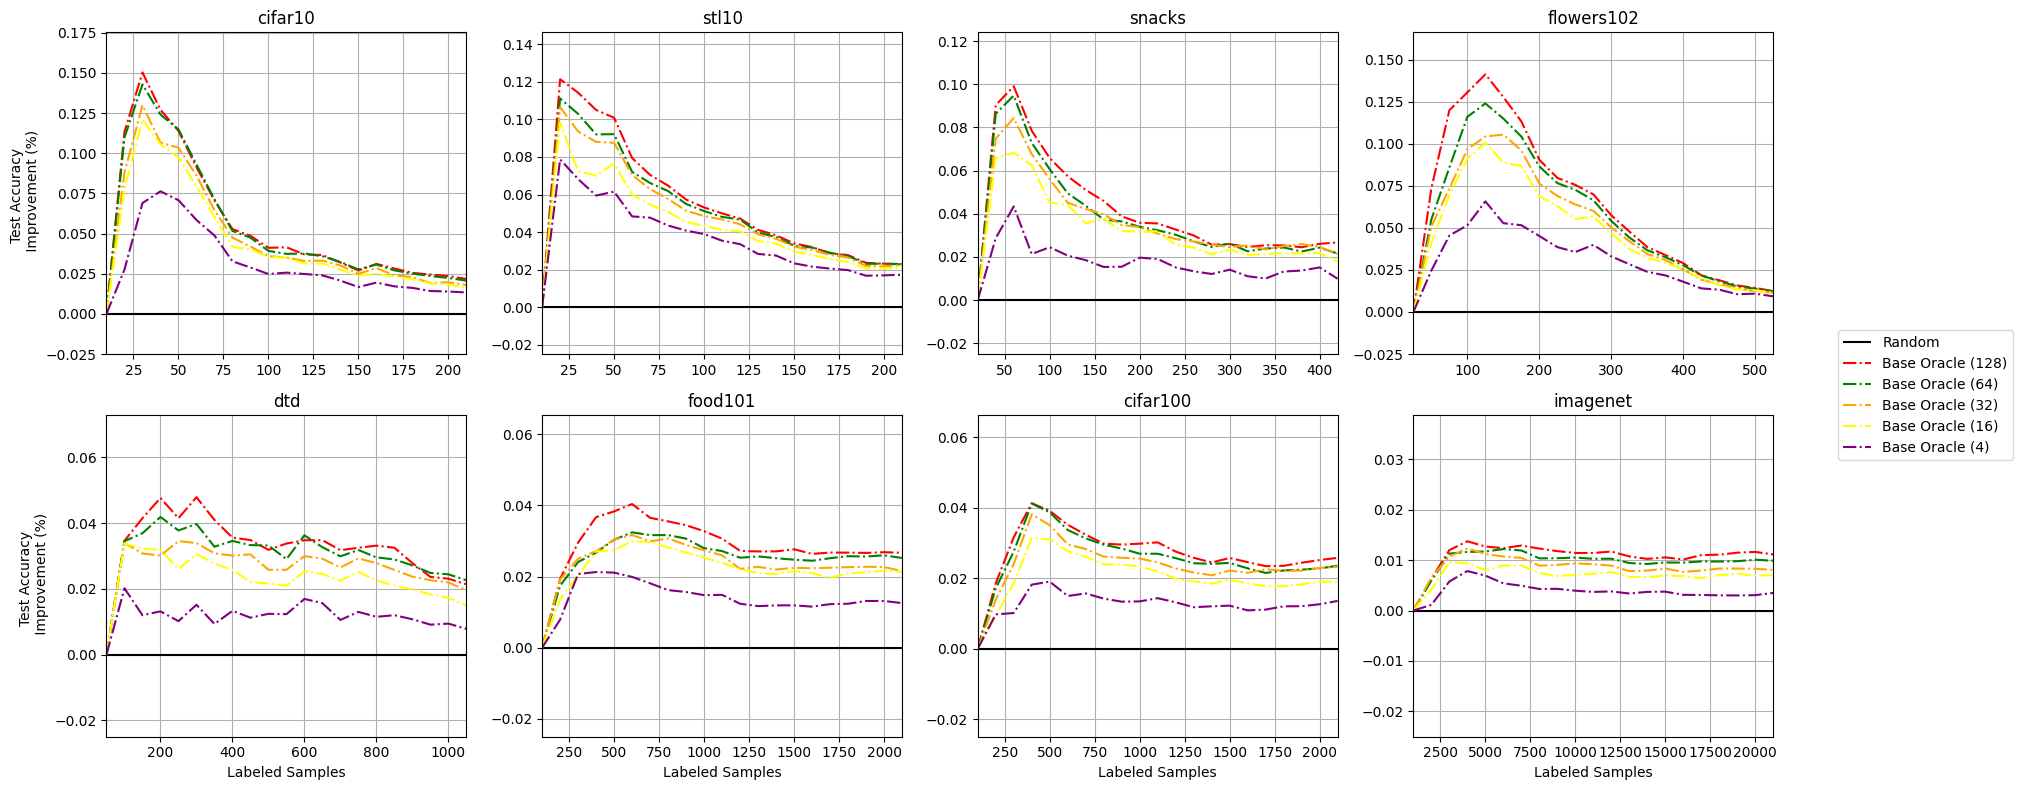

In [5]:
# To remove a query strategy from the plot, comment it out.
Q = {
    'base oracle 4' : {'c':'purple', 'ls':'-.', 'a':1, 'n':'Base Oracle (4)'},
    'base oracle 16' : {'c':'yellow', 'ls':'-.', 'a':1, 'n':'Base Oracle (16)'},
    'base oracle 32' : {'c':'orange', 'ls':'-.', 'a':1, 'n':'Base Oracle (32)'},
    'base oracle 64' : {'c':'green', 'ls':'-.', 'a':1, 'n':'Base Oracle (64)'},
    'base oracle 128' : {'c':'red', 'ls':'-.', 'a':1, 'n':'Base Oracle (128)'},
    'base oracle 256' : {'c':'cyan', 'ls':'-.', 'a':1, 'n':'Base Oracle (256)'},
    'base oracle 512' : {'c':'blue', 'ls':'-.', 'a':1, 'n':'Base Oracle (512)'},
}

fig, ax = plt.subplots(nrows=2, ncols=4, tight_layout=True, figsize=(18, 8))

for i, dset in enumerate(datasets):
    plt.axes(ax[i//4, i%4])
    acqs = datasets[dset]
    x_ticks = [i*acqs for i in range(1, 22)]

    plt.hlines(y=0, xmin=x_ticks[0], xmax=x_ticks[-1], colors='black', linestyles='-', label='Random')
    ylim = (0, 0)
    for strategy, accs in all_acc_curves_strategies[dset].items():
        if strategy in Q:
            values = np.mean(accs, axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0)
            ylim = (min(ylim[0], min(values) - 0.025), max(ylim[1], max(values) + 0.025))
            plt.plot(x_ticks, values, label=Q[strategy]['n'], c=Q[strategy]['c'], linestyle=Q[strategy]['ls'], alpha=Q[strategy]['a'])
    if i // 4 == 1:
        plt.xlabel('Labeled Samples')
    if i % 4 == 0:
        plt.ylabel('Test Accuracy \n Improvement (%)')
    plt.title(dset)
    plt.grid(True)
    plt.xlim((x_ticks[0], x_ticks[-1]))
    plt.ylim(ylim)
    if dset == 'cifar10':
        handles, labels = plt.gca().get_legend_handles_labels()
        
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

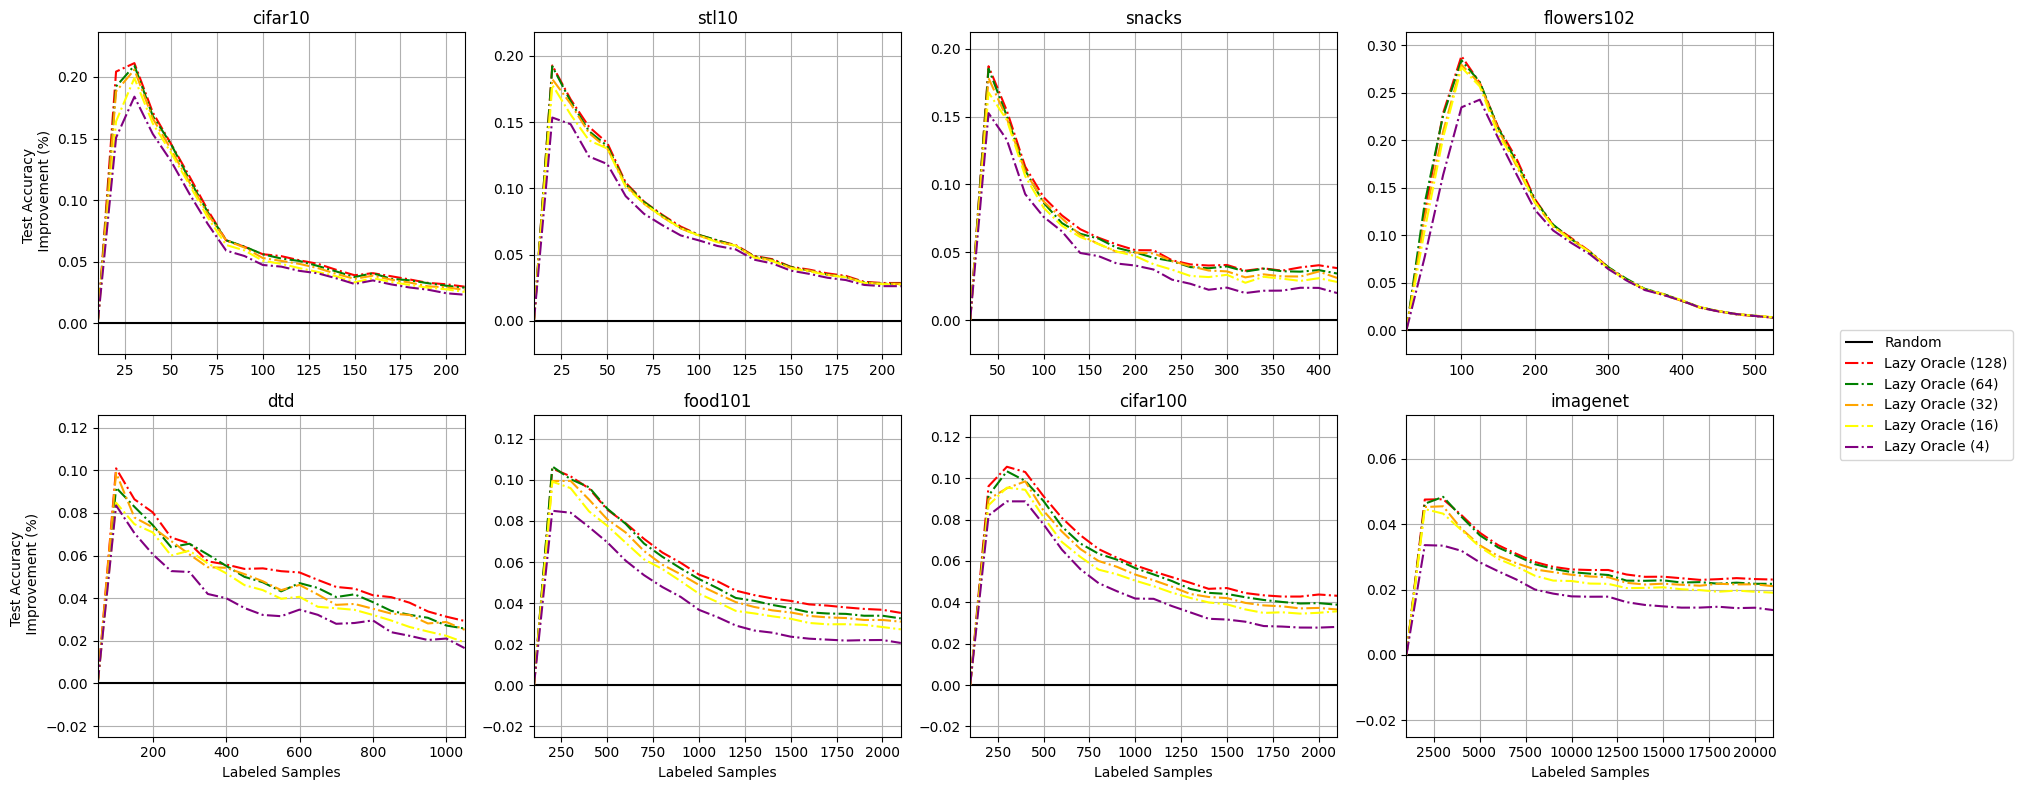

In [6]:
# To remove a query strategy from the plot, comment it out.
Q = {
    'lazy oracle 4' : {'c':'purple', 'ls':'-.', 'a':1, 'n':'Lazy Oracle (4)'},
    'lazy oracle 16' : {'c':'yellow', 'ls':'-.', 'a':1, 'n':'Lazy Oracle (16)'},
    'lazy oracle 32' : {'c':'orange', 'ls':'-.', 'a':1, 'n':'Lazy Oracle (32)'},
    'lazy oracle 64' : {'c':'green', 'ls':'-.', 'a':1, 'n':'Lazy Oracle (64)'},
    'lazy oracle 128' : {'c':'red', 'ls':'-.', 'a':1, 'n':'Lazy Oracle (128)'},
    'lazy oracle 256' : {'c':'cyan', 'ls':'-.', 'a':1, 'n':'Lazy Oracle (256)'},
    'lazy oracle 512' : {'c':'blue', 'ls':'-.', 'a':1, 'n':'Lazy Oracle (512)'},
}

fig, ax = plt.subplots(nrows=2, ncols=4, tight_layout=True, figsize=(18, 8))

for i, dset in enumerate(datasets):
    plt.axes(ax[i//4, i%4])
    acqs = datasets[dset]
    x_ticks = [i*acqs for i in range(1, 22)]

    plt.hlines(y=0, xmin=x_ticks[0], xmax=x_ticks[-1], colors='black', linestyles='-', label='Random')
    ylim = (0, 0)
    for strategy, accs in all_acc_curves_strategies[dset].items():
        if strategy in Q:
            values = np.mean(accs, axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0)
            ylim = (min(ylim[0], min(values) - 0.025), max(ylim[1], max(values) + 0.025))
            plt.plot(x_ticks, values, label=Q[strategy]['n'], c=Q[strategy]['c'], linestyle=Q[strategy]['ls'], alpha=Q[strategy]['a'])
    if i // 4 == 1:
        plt.xlabel('Labeled Samples')
    if i % 4 == 0:
        plt.ylabel('Test Accuracy \n Improvement (%)')
    plt.title(dset)
    plt.grid(True)
    plt.xlim((x_ticks[0], x_ticks[-1]))
    plt.ylim(ylim)
    if dset == 'cifar10':
        handles, labels = plt.gca().get_legend_handles_labels()
        
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

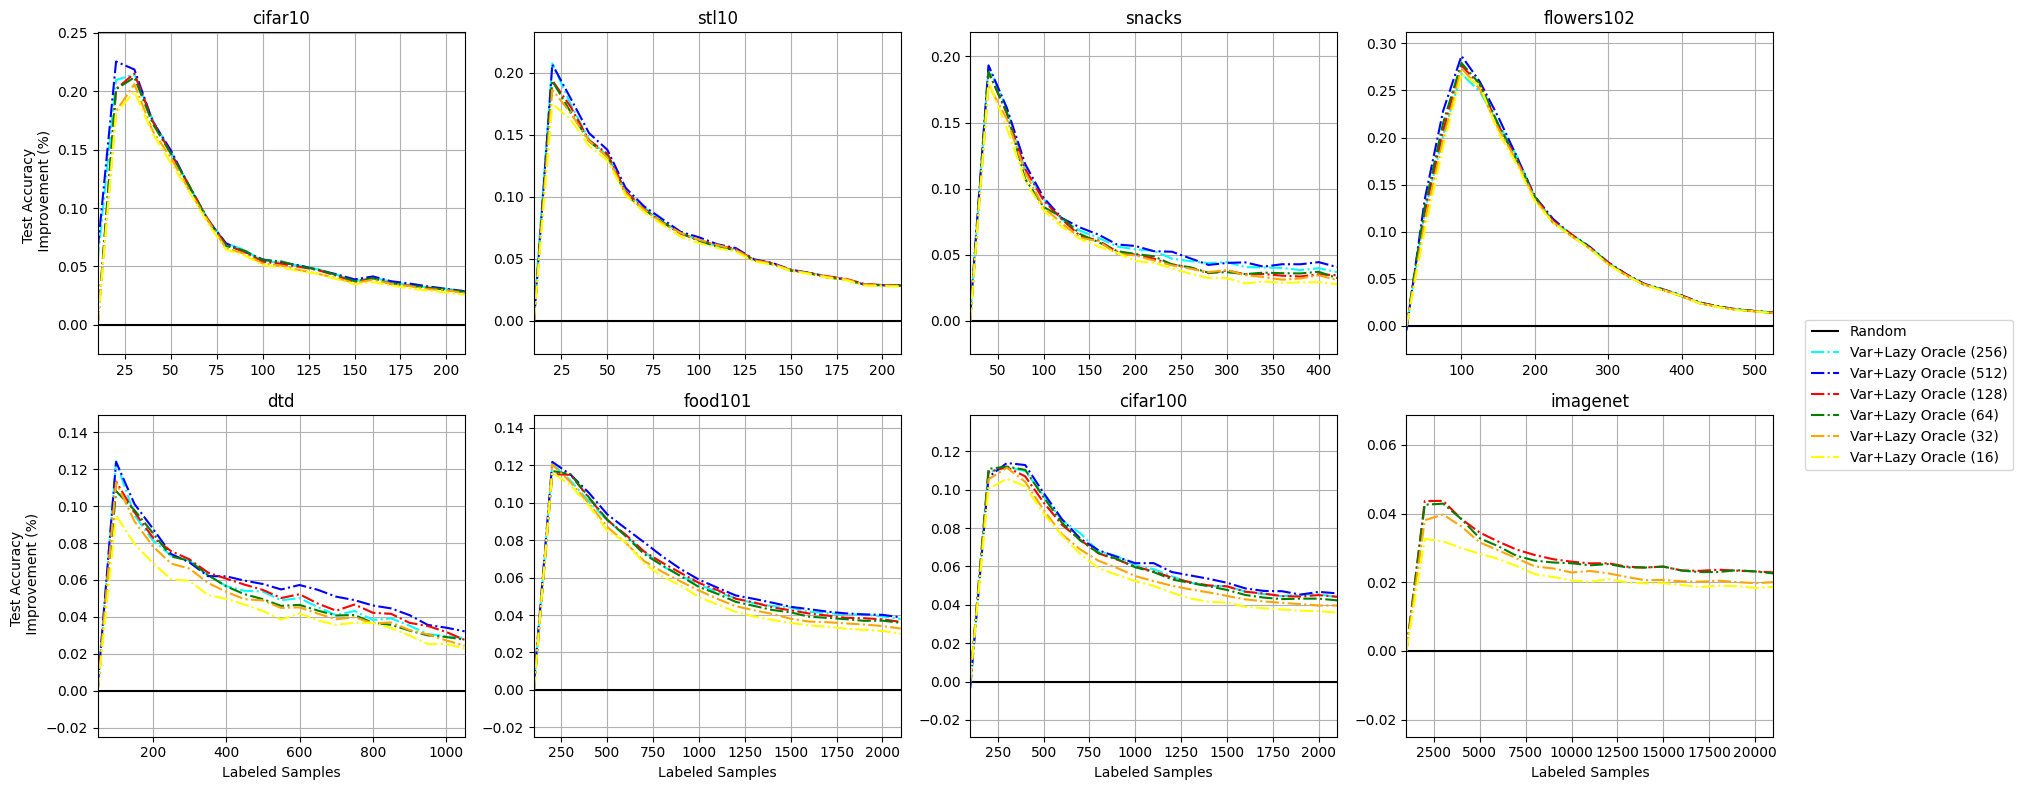

In [7]:
# To remove a query strategy from the plot, comment it out.
Q = {
    'var lazy oracle 16' : {'c':'yellow', 'ls':'-.', 'a':1, 'n':'Var+Lazy Oracle (16)'},
    'var lazy oracle 32' : {'c':'orange', 'ls':'-.', 'a':1, 'n':'Var+Lazy Oracle (32)'},
    'var lazy oracle 64' : {'c':'green', 'ls':'-.', 'a':1, 'n':'Var+Lazy Oracle (64)'},
    'var lazy oracle 128' : {'c':'red', 'ls':'-.', 'a':1, 'n':'Var+Lazy Oracle (128)'},
    'var lazy oracle 256' : {'c':'cyan', 'ls':'-.', 'a':1, 'n':'Var+Lazy Oracle (256)'},
    'var lazy oracle 512' : {'c':'blue', 'ls':'-.', 'a':1, 'n':'Var+Lazy Oracle (512)'},
}

fig, ax = plt.subplots(nrows=2, ncols=4, tight_layout=True, figsize=(18, 8))

for i, dset in enumerate(datasets):
    plt.axes(ax[i//4, i%4])
    acqs = datasets[dset]
    x_ticks = [i*acqs for i in range(1, 22)]

    plt.hlines(y=0, xmin=x_ticks[0], xmax=x_ticks[-1], colors='black', linestyles='-', label='Random')
    ylim = (0, 0)
    for strategy, accs in all_acc_curves_strategies[dset].items():
        if strategy in Q:
            values = np.mean(accs, axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0)
            ylim = (min(ylim[0], min(values) - 0.025), max(ylim[1], max(values) + 0.025))
            plt.plot(x_ticks, values, label=Q[strategy]['n'], c=Q[strategy]['c'], linestyle=Q[strategy]['ls'], alpha=Q[strategy]['a'])
    if i // 4 == 1:
        plt.xlabel('Labeled Samples')
    if i % 4 == 0:
        plt.ylabel('Test Accuracy \n Improvement (%)')
    plt.title(dset)
    plt.grid(True)
    plt.xlim((x_ticks[0], x_ticks[-1]))
    plt.ylim(ylim)
    if dset == 'cifar10':
        handles, labels = plt.gca().get_legend_handles_labels()
        
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

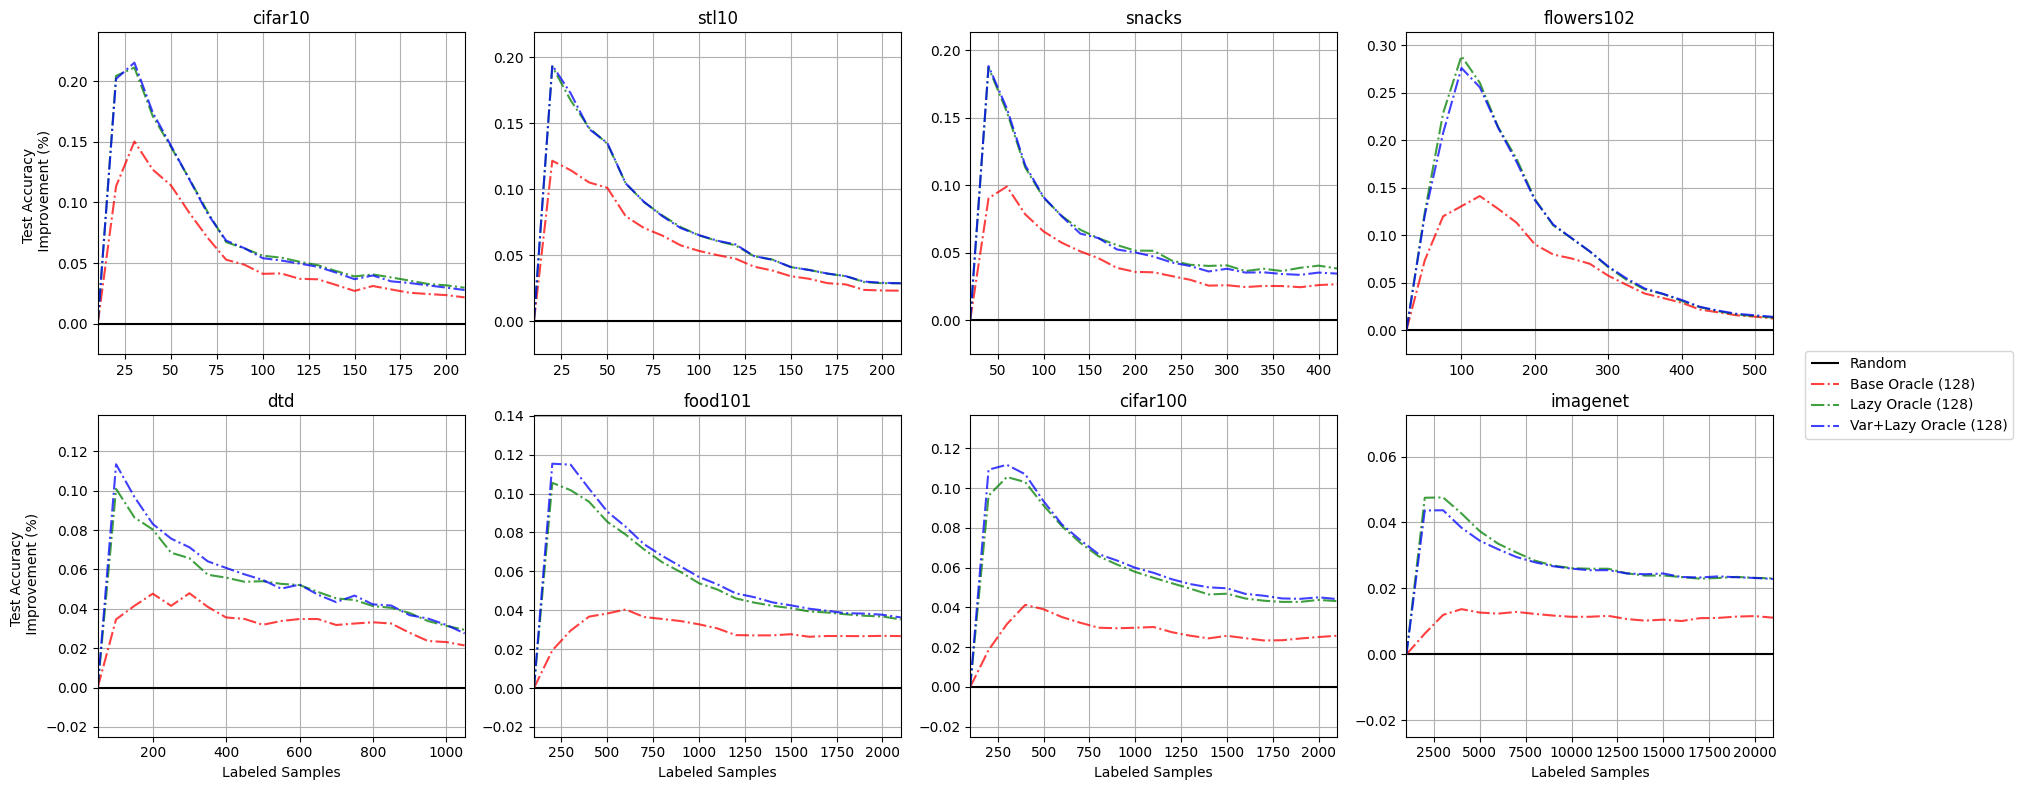

In [8]:
# To remove a query strategy from the plot, comment it out.
Q = {
    'var lazy oracle 128' : {'c':'blue', 'ls':'-.', 'a':.75, 'n':'Var+Lazy Oracle (128)'},
    'lazy oracle 128' : {'c':'green', 'ls':'-.', 'a':.75, 'n':'Lazy Oracle (128)'},
    'base oracle 128' : {'c':'red', 'ls':'-.', 'a':.75, 'n':'Base Oracle (128)'},
}

fig, ax = plt.subplots(nrows=2, ncols=4, tight_layout=True, figsize=(18, 8))

for i, dset in enumerate(datasets):
    plt.axes(ax[i//4, i%4])
    acqs = datasets[dset]
    x_ticks = [i*acqs for i in range(1, 22)]

    plt.hlines(y=0, xmin=x_ticks[0], xmax=x_ticks[-1], colors='black', linestyles='-', label='Random')
    ylim = (0, 0)
    for strategy, accs in all_acc_curves_strategies[dset].items():
        if strategy in Q:
            values = np.mean(accs, axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0)
            ylim = (min(ylim[0], min(values) - 0.025), max(ylim[1], max(values) + 0.025))
            plt.plot(x_ticks, values, label=Q[strategy]['n'], c=Q[strategy]['c'], linestyle=Q[strategy]['ls'], alpha=Q[strategy]['a'])
    if i // 4 == 1:
        plt.xlabel('Labeled Samples')
    if i % 4 == 0:
        plt.ylabel('Test Accuracy \n Improvement (%)')
    plt.title(dset)
    plt.grid(True)
    plt.xlim((x_ticks[0], x_ticks[-1]))
    plt.ylim(ylim)
    if dset == 'cifar10':
        handles, labels = plt.gca().get_legend_handles_labels()
        
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

In [9]:
Q = {
    'var lazy oracle 16' : {'c':'blue', 'ls':'--', 'a':.75, 'n':'Var+Lazy Oracle (16)'},
    'var lazy oracle 32' : {'c':'blue', 'ls':'--', 'a':.75, 'n':'Var+Lazy Oracle (32)'},
    'var lazy oracle 64' : {'c':'blue', 'ls':'--', 'a':.75, 'n':'Var+Lazy Oracle (64)'},
    'var lazy oracle 128' : {'c':'blue', 'ls':':', 'a':.75, 'n':'Var+Lazy Oracle (128)'},
    'var lazy oracle 512' : {'c':'blue', 'ls':'-.', 'a':.75, 'n':'Var+Lazy Oracle (512)'},
    'lazy oracle 4' : {'c':'green', 'ls':'--', 'a':.75, 'n':'Lazy Oracle (4)'},
    'lazy oracle 16' : {'c':'green', 'ls':'--', 'a':.75, 'n':'Lazy Oracle (16)'},
    'lazy oracle 32' : {'c':'green', 'ls':'--', 'a':.75, 'n':'Lazy Oracle (32)'},
    'lazy oracle 64' : {'c':'green', 'ls':'--', 'a':.75, 'n':'Lazy Oracle (64)'},
    'lazy oracle 128' : {'c':'green', 'ls':':', 'a':.75, 'n':'Lazy Oracle (128)'},
    'lazy oracle 512' : {'c':'green', 'ls':'-.', 'a':.75, 'n':'Lazy Oracle (512)'},
    'base oracle 32' : {'c':'red', 'ls':'--', 'a':.75, 'n':'Base Oracle (32)'},
    'base oracle 128' : {'c':'red', 'ls':':', 'a':.75, 'n':'Base Oracle (128)'},
    'base oracle 512' : {'c':'red', 'ls':'-.', 'a':.75, 'n':'Base Oracle (512)'},
    'CrossDomainOracle' : {'c':'pink', 'ls':'-.', 'a':1, 'n':'CrossDomainOracle'}
}

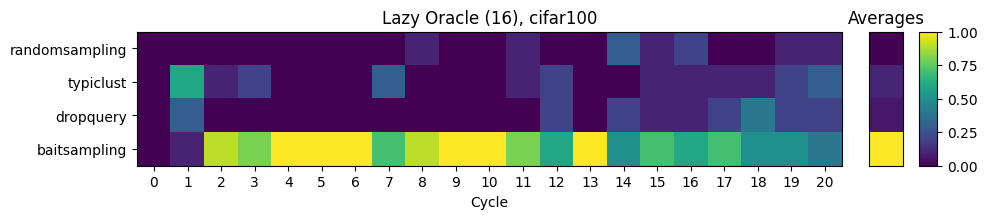

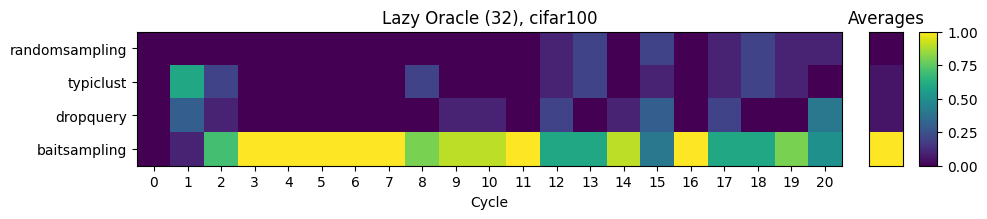

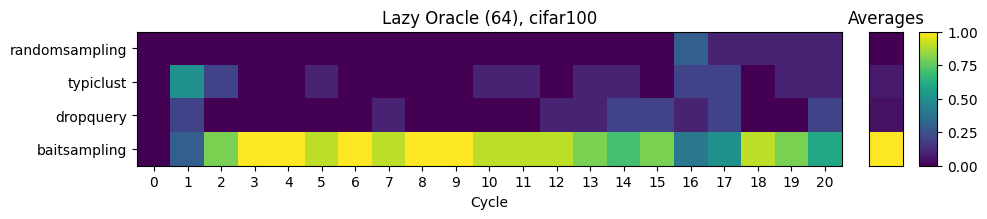

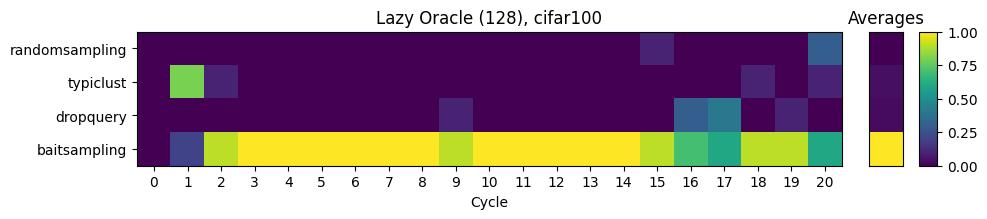

In [10]:
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling']
cmap = 'viridis'
dset = 'cifar100'
query_size = datasets[dset]
n_queries = 21

for strat in ['lazy oracle 16', 'lazy oracle 32', 'lazy oracle 64', 'lazy oracle 128']:
    fig, ax = plt.subplots(nrows=1, ncols=3, width_ratios=[20, 1, .5], figsize=(10, 2))

    image = []
    for sampl_strat in sampling_strategies:
        img = []
        for seed in range(10):
            if len(all_pick_choices[dset][strat]) > seed:
                im = []
                for i in range(n_queries):
                    if i == 0:
                        im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                    else:
                        im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                img.append(im)
        image.append(img)
    image_arr = np.array(image)
    pick_choices = np.mean(image_arr, axis=1)
    avg_pick_choices = np.mean(pick_choices, axis=-1, keepdims=True)

    cax1 = ax[0].imshow(pick_choices)
    ax[0].set_xlabel('Cycle')
    ax[0].set_xticks(range(n_queries))
    ax[0].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
    ax[0].set_title(Q[strat]['n']+', '+dset)

    ax[1].imshow(avg_pick_choices)
    ax[1].set_title('Averages')
    ax[1].set_xticks([])
    ax[1].set_yticks([])

    cbar = fig.colorbar(cax1, cax=ax[2], orientation='vertical')
    plt.tight_layout()
    plt.show()

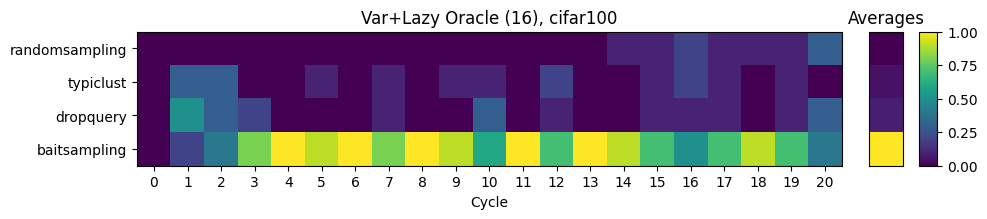

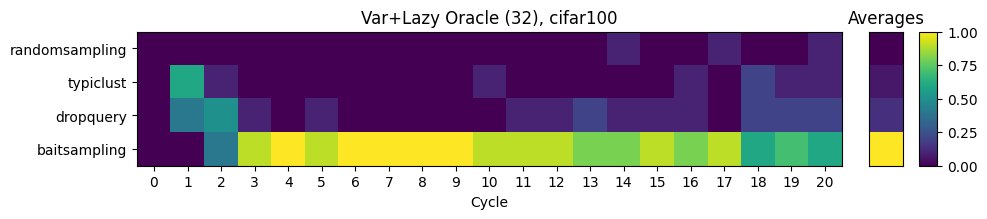

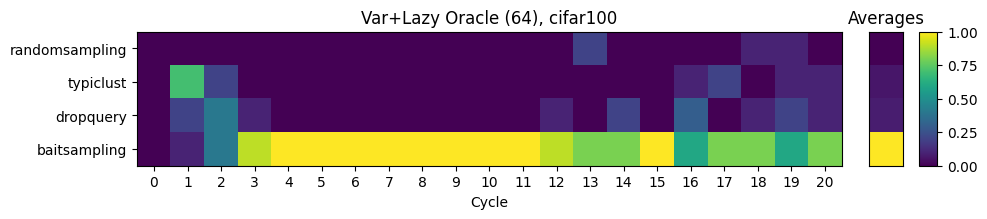

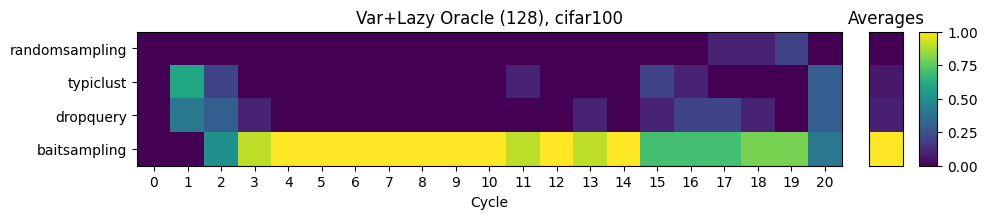

In [11]:
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling']
cmap = 'viridis'
dset = 'cifar100'
query_size = datasets[dset]
n_queries = 21

for strat in ['var lazy oracle 16', 'var lazy oracle 32', 'var lazy oracle 64', 'var lazy oracle 128']:
    fig, ax = plt.subplots(nrows=1, ncols=3, width_ratios=[20, 1, .5], figsize=(10, 2))

    image = []
    for sampl_strat in sampling_strategies:
        img = []
        for seed in range(10):
            if len(all_pick_choices[dset][strat]) > seed:
                im = []
                for i in range(n_queries):
                    if i == 0:
                        im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                    else:
                        im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                img.append(im)
        image.append(img)
    image_arr = np.array(image)
    pick_choices = np.mean(image_arr, axis=1)
    avg_pick_choices = np.mean(pick_choices, axis=-1, keepdims=True)

    cax1 = ax[0].imshow(pick_choices)
    ax[0].set_xlabel('Cycle')
    ax[0].set_xticks(range(n_queries))
    ax[0].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
    ax[0].set_title(Q[strat]['n']+', '+dset)

    ax[1].imshow(avg_pick_choices)
    ax[1].set_title('Averages')
    ax[1].set_xticks([])
    ax[1].set_yticks([])

    cbar = fig.colorbar(cax1, cax=ax[2], orientation='vertical')
    plt.tight_layout()
    plt.show()

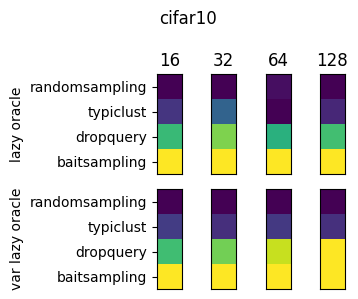

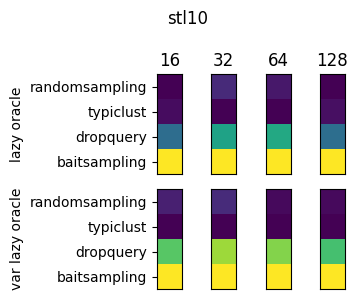

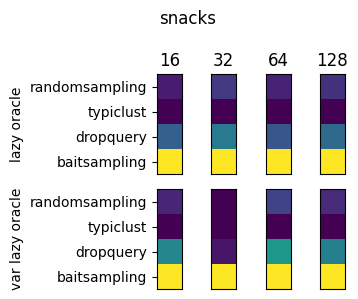

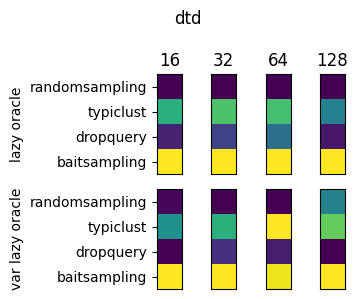

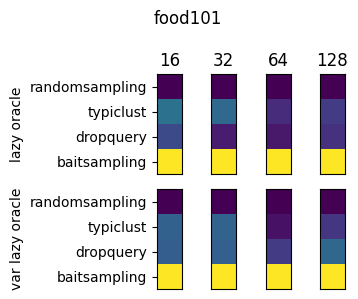

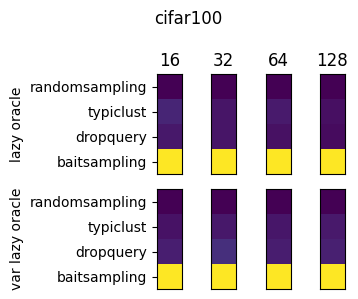

In [12]:
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling']
cmap = 'viridis'
n_queries = 21

for dset in datasets:
    if dset not in ['flowers102', 'imagenet']: # TODO: To be done after their experiments finished
        fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(4, 3))
        fig.suptitle(dset)
        query_size = datasets[dset]
        for j, bs in enumerate(['16', '32', '64', '128']):
            for k, strategy in enumerate(['lazy oracle', 'var lazy oracle']):
                strat = strategy + ' ' + bs
                image = []
                for sampl_strat in sampling_strategies:
                    img = []
                    for seed in range(10):
                        im = []
                        if seed < len(all_pick_choices[dset][strat]):
                            for i in range(n_queries):
                                if i == 0:
                                    im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                                else:
                                    im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                            img.append(im)
                    image.append(img)
                image = np.array(image)
                img = np.mean(image, axis=1)
                img_avg = np.mean(img, axis=-1, keepdims=True)

                ax[k][j].imshow(img_avg)
                ax[k][j].set_xticks([])
                if j == 0:
                    ax[k][j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
                else:
                    ax[k][j].set_yticks([])

                if j == 0:
                    ax[k][j].set_ylabel(strategy)
                if k == 0:
                    ax[k][j].set_title(bs)

        plt.tight_layout()
        plt.show()

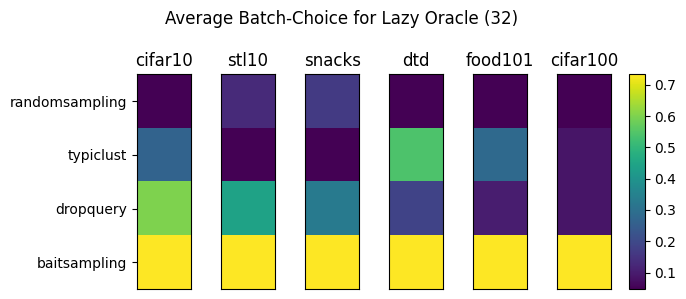

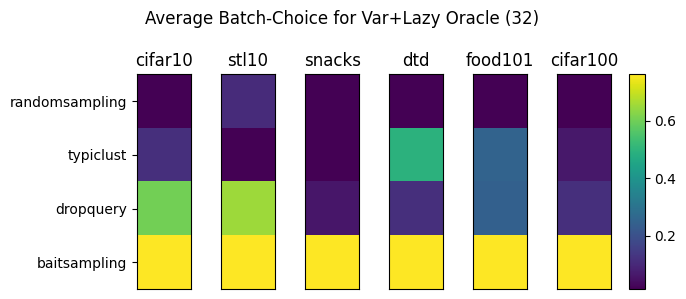

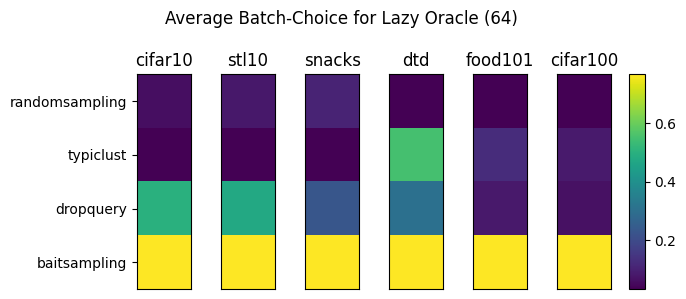

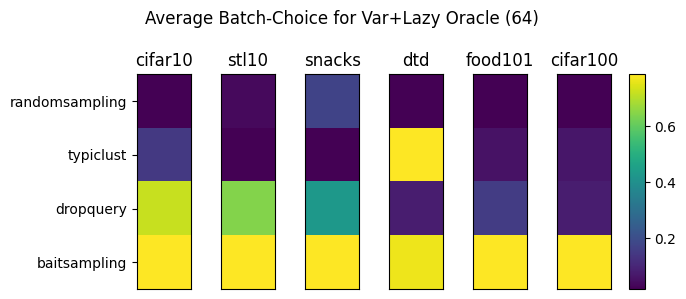

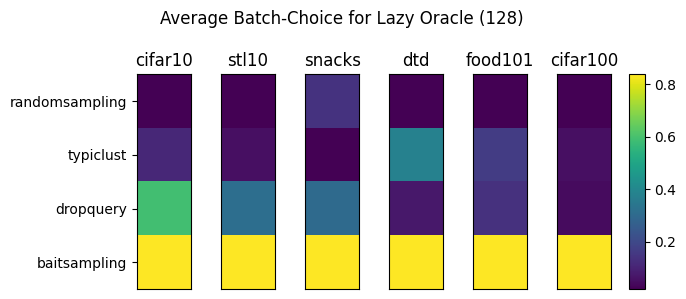

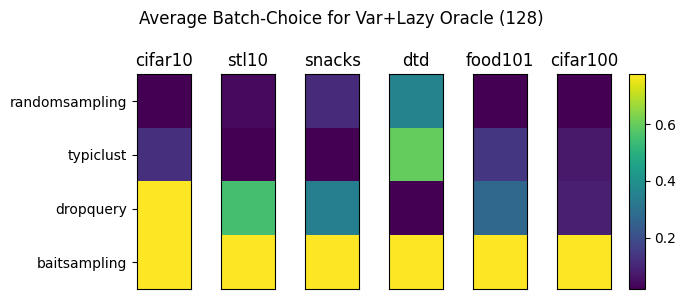

In [16]:
sampling_strategies = ['randomsampling', 'typiclust', 'dropquery', 'baitsampling']
cmap = 'viridis'
n_queries = 21

for strat in ['lazy oracle 32', 'var lazy oracle 32', 'lazy oracle 64', 'var lazy oracle 64', 'lazy oracle 128', 'var lazy oracle 128']:
    fig, ax = plt.subplots(nrows=1, ncols=7, figsize=(7, 3), width_ratios=[1, 1, 1, 1, 1, 1, .2])
    fig.suptitle("Average Batch-Choice for "+Q[strat]['n'])
    j = 0
    for dset in datasets:
        if dset not in ['flowers102', 'imagenet']: # TODO: To be done after their experiments finished
            query_size = datasets[dset]
            image = []
            for sampl_strat in sampling_strategies:
                img = []
                for seed in range(10):
                    im = []
                    if seed < len(all_pick_choices[dset][strat]):
                        for i in range(n_queries):
                            if i == 0:
                                im.append(all_pick_choices[dset][strat][seed][sampl_strat][i].value)
                            else:
                                im.append(1 if (all_pick_choices[dset][strat][seed][sampl_strat][i].value > all_pick_choices[dset][strat][seed][sampl_strat][i-1].value) else 0)
                        img.append(im)
                image.append(img)
            image = np.array(image)
            img = np.mean(image, axis=1)
            img_avg = np.mean(img, axis=-1, keepdims=True)

            c1 = ax[j].imshow(img_avg)
            ax[j].set_xticks([])
            if j == 0:
                ax[j].set_yticks(ticks=range(len(sampling_strategies)), labels=sampling_strategies)
            else:
                ax[j].set_yticks([])
            ax[j].set_title(dset)

            j += 1

    fig.colorbar(c1, cax=ax[-1])
    plt.tight_layout()
    plt.show()

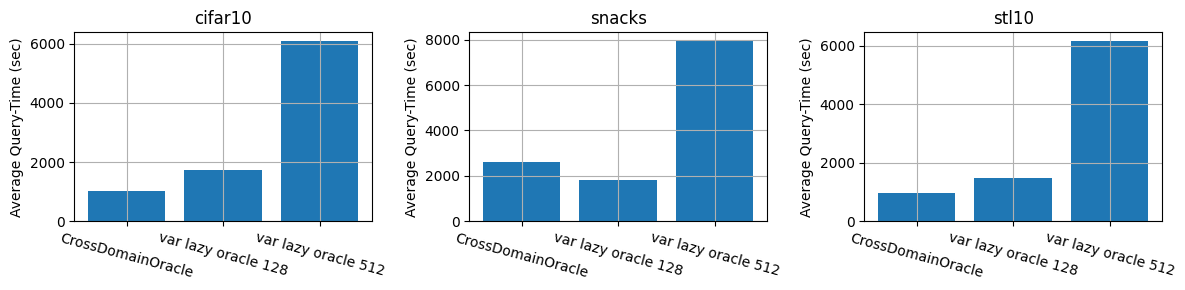

In [14]:
# Time Comparison
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,3), tight_layout=True)

for i, dset in enumerate(['cifar10', 'snacks', 'stl10']):
    plt.axes(ax[i])
    D = {}
    for strat in ['CrossDomainOracle', 'var lazy oracle 128', 'var lazy oracle 512']:
        qts = np.sum(np.mean(query_times[dset][strat], axis=0))
        D[strat] = qts
    plt.bar(range(len(D)), list(D.values()), align='center')
    plt.xticks(ticks=range(len(D)), labels=list(D.keys()), rotation=345)
    plt.title(dset)
    plt.ylabel('Average Query-Time (sec)')
    plt.grid(True)
    
plt.show()